In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print("Number of rows and columns:", df.shape)
print()
print("Column data types:")
print(df.dtypes)

Number of rows and columns: (8807, 12)

Column data types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [4]:
print("Unique show_id:", df['show_id'].nunique())
print("Unique titles:", df['title'].nunique())
print()
print(df['type'].value_counts())

Unique show_id: 8807
Unique titles: 8807

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


## Dataset Understanding

This dataset contains metadata for movies and TV shows available on Netflix as of
the data collection date.

- **Rows:** 8,807 | **Columns:** 12
- **Grain:** Each row represents one unique title (movie or TV show)
- **Primary key:** show_id
- **Numerical features:** release_year (only true numeric column)
- **Categorical features:** type, director, cast, country, rating, listed_in
- **Text features:** title, description
- **Needs conversion:** date_added (currently text, should be datetime), duration
  (currently text like "90 min" or "2 Seasons", needs separating by type)

The dataset includes 6,131 Movies and 2,676 TV Shows.

In [5]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percent.round(2)})

,Missing Values,Percentage
show_id,0,0.00
type,0,0.00
title,0,0.00
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
release_year,0,0.00
rating,4,0.05
duration,3,0.03


In [6]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df = df.dropna(subset=['date_added', 'rating', 'duration'])

print("New shape:", df.shape)
print()
print("Remaining missing values:")
print(df.isnull().sum())

New shape: (8790, 12)

Remaining missing values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['date_added'].head()

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24


In [9]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [10]:
df[df['rating'].isin(['74 min', '84 min', '66 min'])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [11]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

**Note:** Initial inspection of the `rating` column revealed invalid values
like "74 min", "84 min", and "66 min".  Duration values misplaced into the
rating column. After cleaning missing values (which removed rows with incomplete
date_added/rating/duration data), these invalid entries were no longer present,
confirming the rating column now only contains genuine age ratings.

In [12]:
df[df['type'] == 'Movie']['duration'].head()
print()
df[df['type'] == 'TV Show']['duration'].head()

,duration
1,2 Seasons
2,1 Season
3,1 Season
4,2 Seasons
5,1 Season


In [14]:
df['duration_minutes'] = df[df['type'] == 'Movie']['duration'].str.extract(r'(\d+)').astype(float)
df['duration_seasons'] = df[df['type'] == 'TV Show']['duration'].str.extract(r'(\d+)').astype(float)

df[['type', 'duration', 'duration_minutes', 'duration_seasons']].head(6)

,type,duration,duration_minutes,duration_seasons
0,Movie,90 min,90.0,NaN
1,TV Show,2 Seasons,NaN,2.0
2,TV Show,1 Season,NaN,1.0
3,TV Show,1 Season,NaN,1.0
4,TV Show,2 Seasons,NaN,2.0
5,TV Show,1 Season,NaN,1.0


## Cleaning Summary

| Issue Found | Action Taken |
|---|---|
| Missing director (2,634 rows, 29.91%) | Filled with "Unknown" — too large to drop |
| Missing cast (825 rows, 9.37%) | Filled with "Unknown" — too large to drop |
| Missing country (831 rows, 9.44%) | Filled with "Unknown" — excluded from country-specific analysis later |
| Missing date_added (10 rows) | Removed — too small to impact analysis |
| Missing rating (4 rows) | Removed — too small to impact analysis |
| Missing duration (3 rows) | Removed — too small to impact analysis |
| Duplicates | None found |
| Invalid rating values ("74 min", "84 min", "66 min") | Resolved automatically — these rows were among those dropped for missing date_added/duration |
| date_added stored as text | Converted to datetime |
| duration stored as mixed text ("90 min" / "2 Seasons") | Split into two numeric columns: duration_minutes (Movies) and duration_seasons (TV Shows) |
| Column names | Already in clean lowercase snake_case — confirmed, no changes needed |

**Final clean dataset:** 8,790 rows × 14 columns (12 original + 2 new duration columns)

In [15]:
df[['release_year', 'duration_minutes', 'duration_seasons']].describe()

,release_year,duration_minutes,duration_seasons
count,8790.000000,6126.000000,2664.000000
mean,2014.183163,99.584884,1.751877
std,8.825466,28.283225,1.550622
min,1925.000000,3.000000,1.000000
25%,2013.000000,87.000000,1.000000
50%,2017.000000,98.000000,1.000000
75%,2019.000000,114.000000,2.000000
max,2021.000000,312.000000,17.000000


In [16]:
df[df['duration_minutes'] == 312]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons
4253,s4254,Movie,Black Mirror: Bandersnatch,Unknown,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,2018-12-28,2018,TV-MA,312 min,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question...",312.0,NaN


In [17]:
type_counts = df['type'].value_counts()
type_counts

,count
type,
Movie,6126
TV Show,2664


In [18]:
df['year_added'] = df['date_added'].dt.year
content_by_year = df['year_added'].value_counts().sort_index()
content_by_year

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,426


In [19]:
df[df['year_added'] == 2021]['date_added'].max()

Timestamp('2021-09-25 00:00:00')

**Data Completeness Note:** The dataset's `date_added` values only go up to September
25, 2021 — so the apparent decline in 2021 additions is partly due to incomplete data
for that year, not necessarily a real slowdown in content additions.

In [20]:
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
top_countries

,count
country,
United States,2809
India,972
United Kingdom,418
Japan,243
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


In [21]:
rating_counts = df['rating'].value_counts()
rating_counts

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


In [22]:
all_genres = df['listed_in'].str.split(', ').explode()
top_genres = all_genres.value_counts().head(10)
top_genres

,count
listed_in,
International Movies,2752
Dramas,2426
Comedies,1674
International TV Shows,1349
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641


## EDA Summary

**Summary statistics:** Average movie runtime is ~100 minutes (range: 3-312 min);
average TV show length is ~1.75 seasons (range: 1-17 seasons). Release years span
nearly a century, from 1925 to 2021.

**Key patterns found:**
1. **Movies vs TV Shows** — Movies (6,126) outnumber TV Shows (2,664) by roughly 2-to-1.
2. **Content added by year** — Additions grew sharply from 2015-2019, peaking at 2,016
   titles in 2019. The apparent 2021 decline is partly due to incomplete data (dataset
   only covers through September 2021).
3. **Top content-producing countries** — The United States leads with 2,809 titles,
   nearly 3x India (#2, 972 titles), reflecting Netflix's US origins with India as a
   strong secondary market.
4. **Most common ratings** — TV-MA (3,205) and TV-14 (2,157) dominate, showing the
   catalog skews toward mature/teen audiences rather than children's content.
5. **Most common genres** — International Movies (2,752) and Dramas (2,426) are the
   most frequent genres, consistent with strong international content contribution.

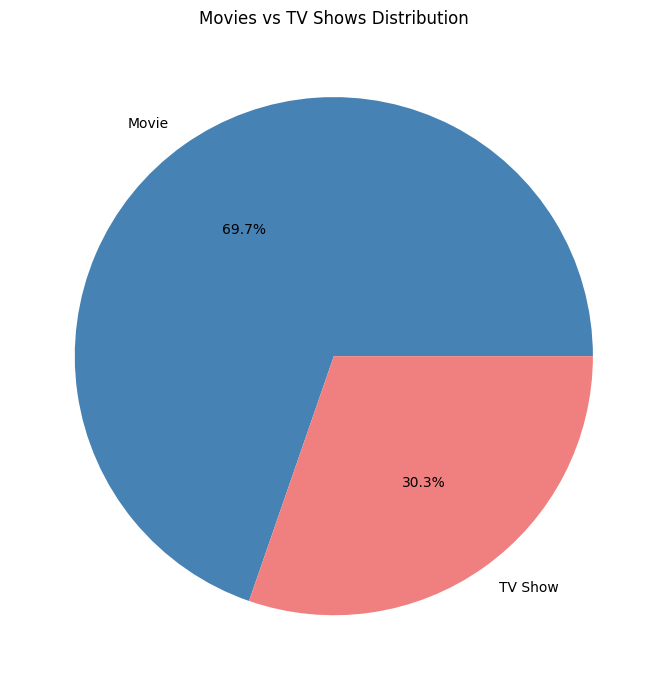

In [23]:
plt.figure(figsize=(7,7))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', colors=['steelblue', 'lightcoral'])
plt.title('Movies vs TV Shows Distribution')
plt.tight_layout()
plt.show()

**Chart 1 Finding:** Movies make up 69.7% of the catalog, with TV Shows at 30.3%.

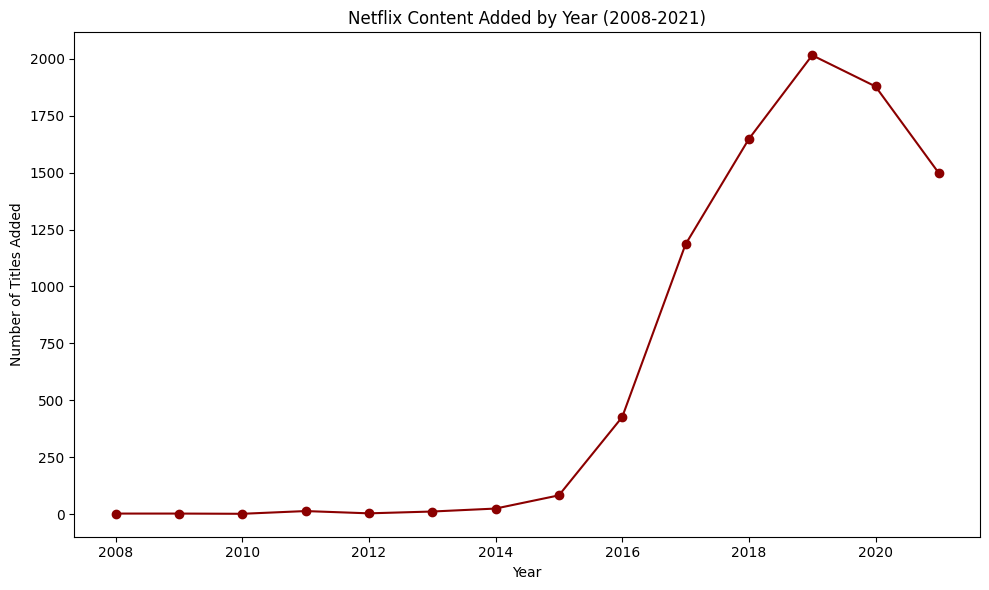

In [24]:
plt.figure(figsize=(10,6))
content_by_year.plot(kind='line', marker='o', color='darkred')
plt.title('Netflix Content Added by Year (2008-2021)')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.tight_layout()
plt.show()

**Chart 2 Finding:** Content additions were small before 2015, then grew explosively
between 2016-2019, peaking at over 2,000 titles in 2019. The drop after 2019 should be
read cautiously. 2021 data is incomplete (only through September), so the true decline
may be smaller than it appears.

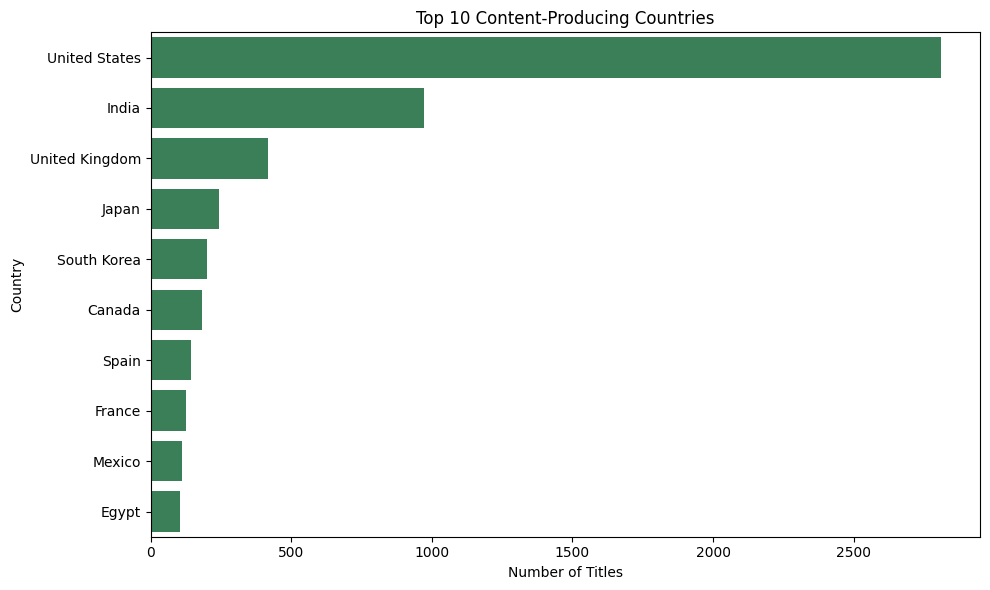

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, color='seagreen')
plt.title('Top 10 Content-Producing Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**Chart 3 Finding:** The United States is by far the largest content producer with
2,809 titles, followed by India at 972. These two countries contribute a
disproportionate share of the catalog compared to all other countries combined.

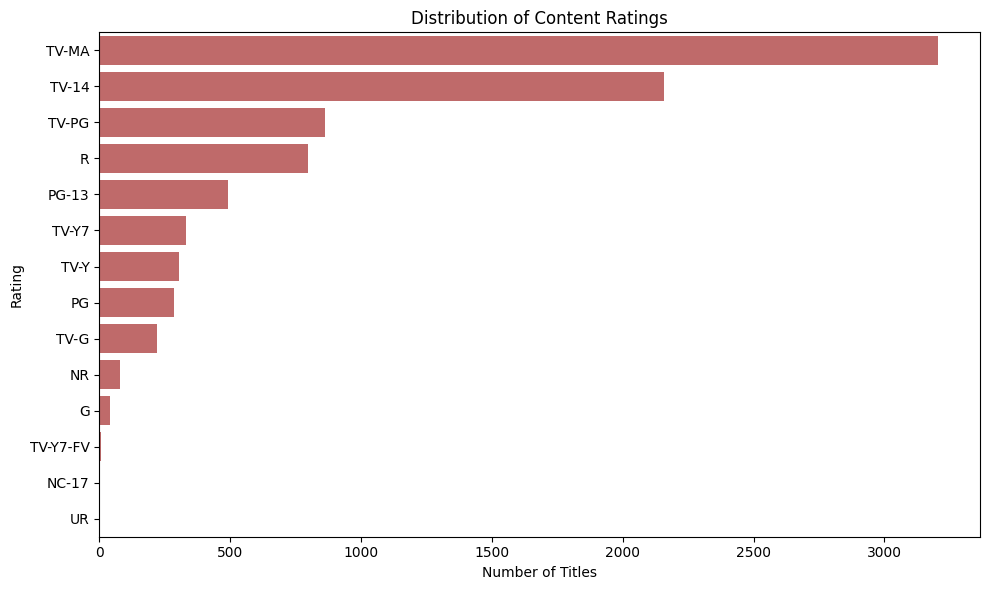

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(x=rating_counts.values, y=rating_counts.index, color='indianred')
plt.title('Distribution of Content Ratings')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

**Chart 4 Finding:** TV-MA and TV-14 are by far the most common ratings, together
accounting for the majority of titles. This confirms the catalog leans toward mature
and teen content rather than children's programming.

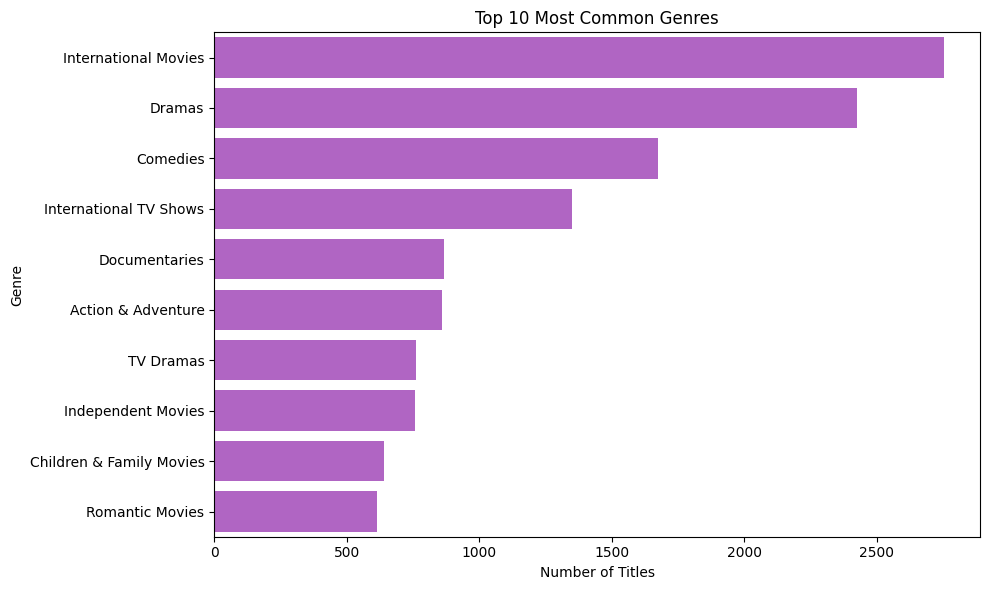

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, color='mediumorchid')
plt.title('Top 10 Most Common Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

**Chart 5 Finding:** International Movies and Dramas are the most common genres,
together reflecting Netflix's strong international catalog and the universal appeal
of drama content.

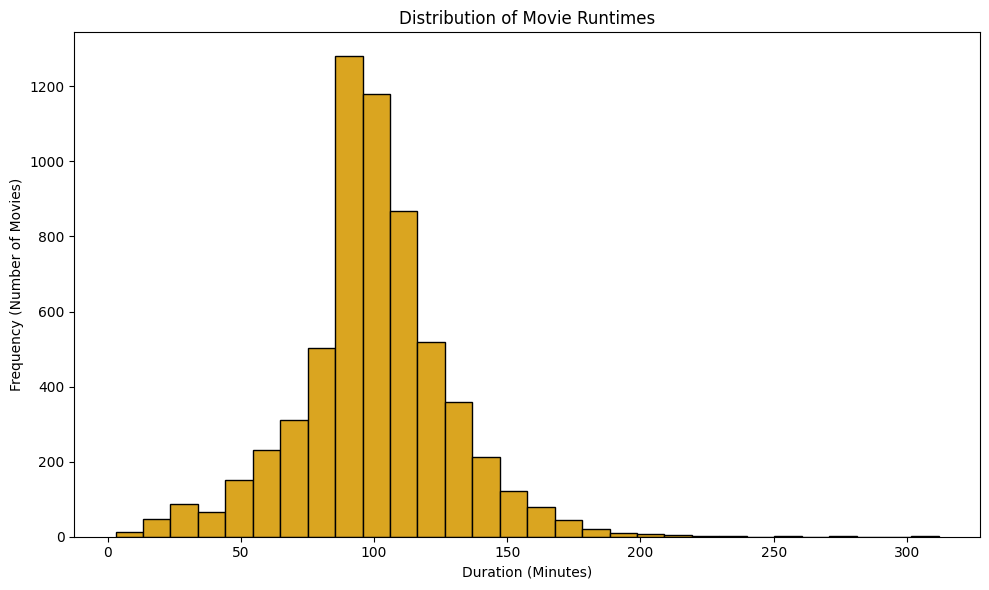

In [28]:
plt.figure(figsize=(10,6))
plt.hist(df['duration_minutes'].dropna(), bins=30, color='goldenrod', edgecolor='black')
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency (Number of Movies)')
plt.tight_layout()
plt.show()

**Chart 6 Finding:** Most movies run between 80-120 minutes, with the distribution
roughly bell-shaped. A small number of
much longer titles (over 200 minutes) form a long tail, including the unusual case
of Black Mirror: Bandersnatch at 312 minutes (an interactive film with multiple story paths).

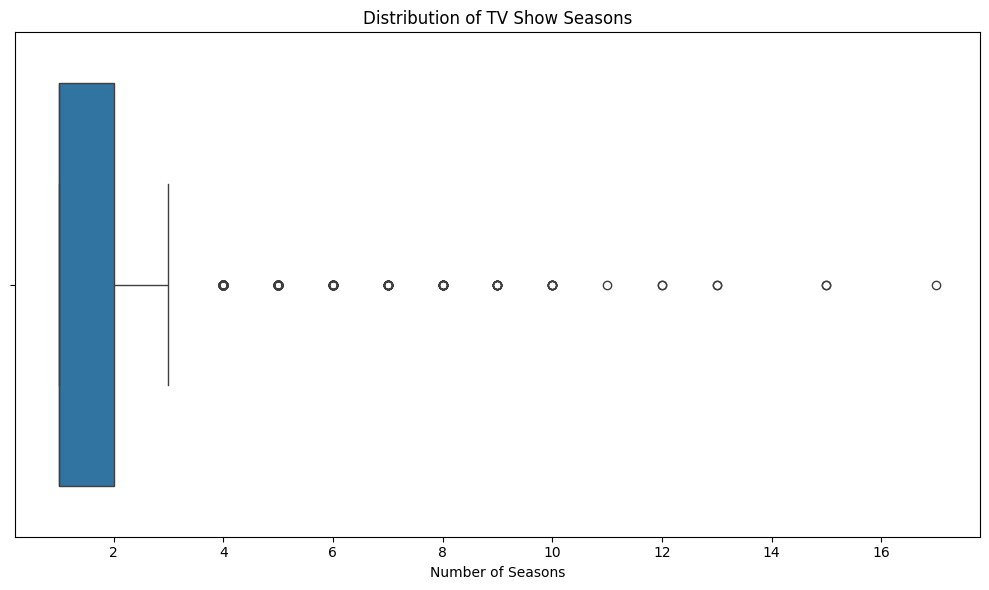

In [30]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['duration_seasons'].dropna())
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.tight_layout()
plt.show()

**Chart 7 Finding:** The vast majority of TV shows have only 1-2 seasons, shown by
the compact box. Shows running longer than 3 seasons are statistical outliers (the
circles), with one extreme case reaching 17 seasons which may be a long-running series.

## Visualization Summary

Seven visualizations were created, covering all chart types requested in the brief:

| # | Chart Type | Topic | Key Takeaway |
|---|---|---|---|
| 1 | Pie | Movies vs TV Shows | Movies make up 69.7% of the catalog |
| 2 | Line | Content added by year | Sharp growth 2016-2019, peaking at 2,016 titles in 2019 |
| 3 | Bar | Top content-producing countries | US leads with 2,809 titles, India second at 972 |
| 4 | Bar | Content ratings distribution | TV-MA and TV-14 dominate, confirming mature/teen skew |
| 5 | Bar | Most common genres | International Movies and Dramas lead |
| 6 | Histogram | Movie runtime distribution | Most movies run 80-120 minutes |
| 7 | Box Plot | TV show seasons distribution | Most shows have 1-2 seasons; longer runs are outliers |

## Key Insights

1. Movies make up most of the catalog at 69.7%, with TV Shows at 30.3% (Chart 1).
   This shows Netflix's content is still mainly built around movies rather than series.

2. Netflix's content additions grew very slowly before 2015, then exploded between
   2016 and 2019, peaking at over 2,000 titles in 2019 (Chart 2). The drop after 2019
   should be read carefully though, since the 2021 data is incomplete and only goes
   up to September.

3. The United States produces by far the most content with 2,809 titles, almost three
   times more than India in second place with 972 (Chart 3). This makes sense given
   Netflix started as a US company, with India growing into a strong secondary market.

4. TV-MA and TV-14 are the most common ratings on the platform (Chart 4), showing
   that Netflix's catalog leans more toward mature and teen audiences than children's
   content.

5. International Movies and Dramas are the most common genres (Chart 5), which lines
   up with the strong international content coming from countries like the US, India,
   and the UK.